In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [2]:
df=pd.read_csv("loan_approval_data.csv")

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


HANDLING MISSING VALUES 

In [4]:
categorical_cols=df.select_dtypes(include=["str"]).columns
numrical_cols=df.select_dtypes(include=["number"]).columns

In [5]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [6]:
from sklearn.impute import SimpleImputer

# Handling missing numerical values
num_imput=SimpleImputer(strategy="mean")
df[numrical_cols]=num_imput.fit_transform(df[numrical_cols])

#handling missing categorical values
cat_imput=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imput.fit_transform(df[categorical_cols])

EDA -> Exploratory Data Analysis

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

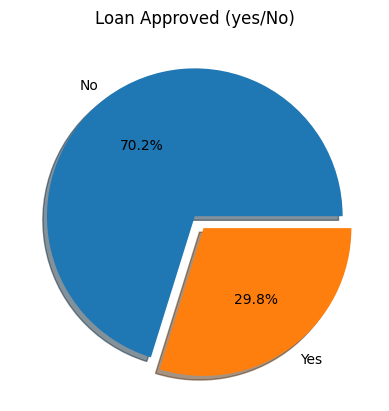

In [7]:
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%",shadow=True,explode=[0,0.1])
plt.title("Loan Approved (yes/No)")
classes_count

[Text(0, 0, '643'), Text(0, 0, '357')]

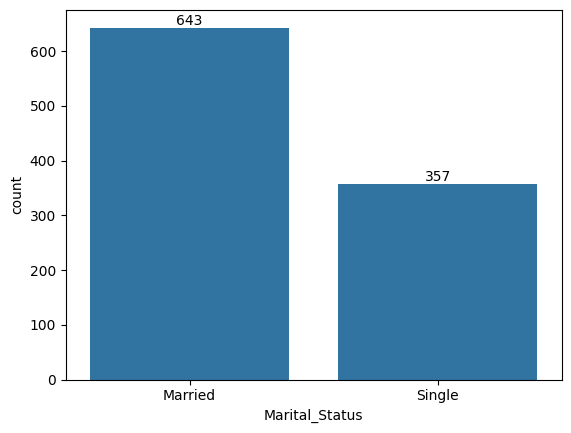

In [8]:
#   Analyze Gender:-
# gender_cnt=df["Gender"].value_counts()
# ax=sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

#   Analyze Education Level 
# education_level=df["Education_Level"].value_counts()
# ax=sns.barplot(education_cnt)
# ax.bar_label(ax.containers[0])

#   Analyze Merital status
married_cnt=df["Marital_Status"].value_counts()
ax=sns.barplot(married_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

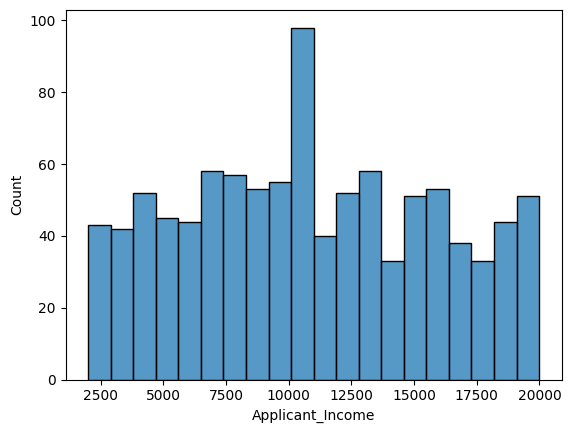

In [9]:
#   Analyze income
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

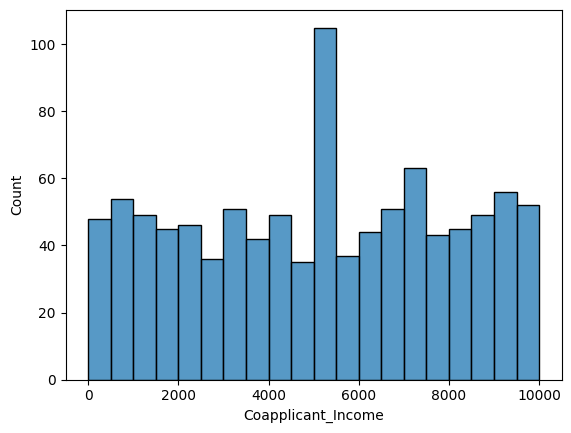

In [10]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

In [11]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


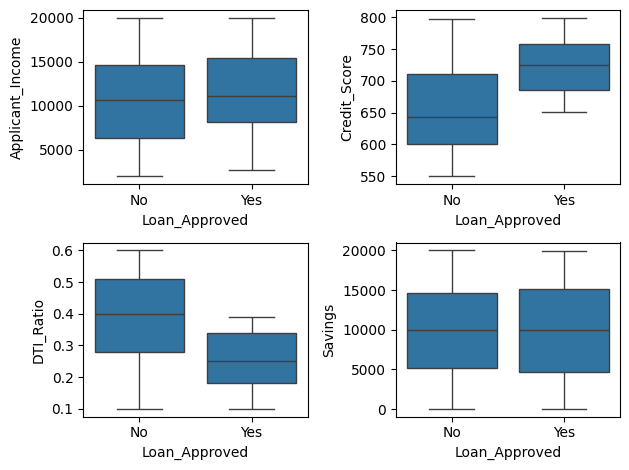

In [12]:
# Checking Outliers
fix,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

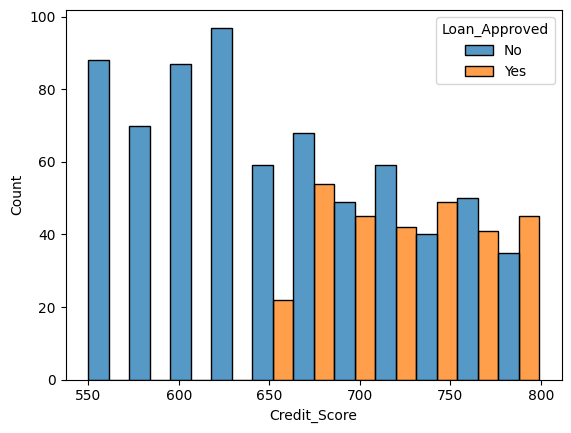

In [13]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge"
)

In [14]:
# Remove Applicant Id
df=df.drop("Applicant_ID",axis=1)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [16]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


In [17]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Gender","Property_Area","Employer_Category"]
one_hot=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=one_hot.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=one_hot.get_feature_names_out(cols),
                        index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [35]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.2809,405769.0,9.786729
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0900,385641.0,7.958926
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0400,454276.0,8.908018
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0961,335241.0,9.544309
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0841,519841.0,9.494391


Correlation Heatmap

In [18]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()
corr_matrix
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

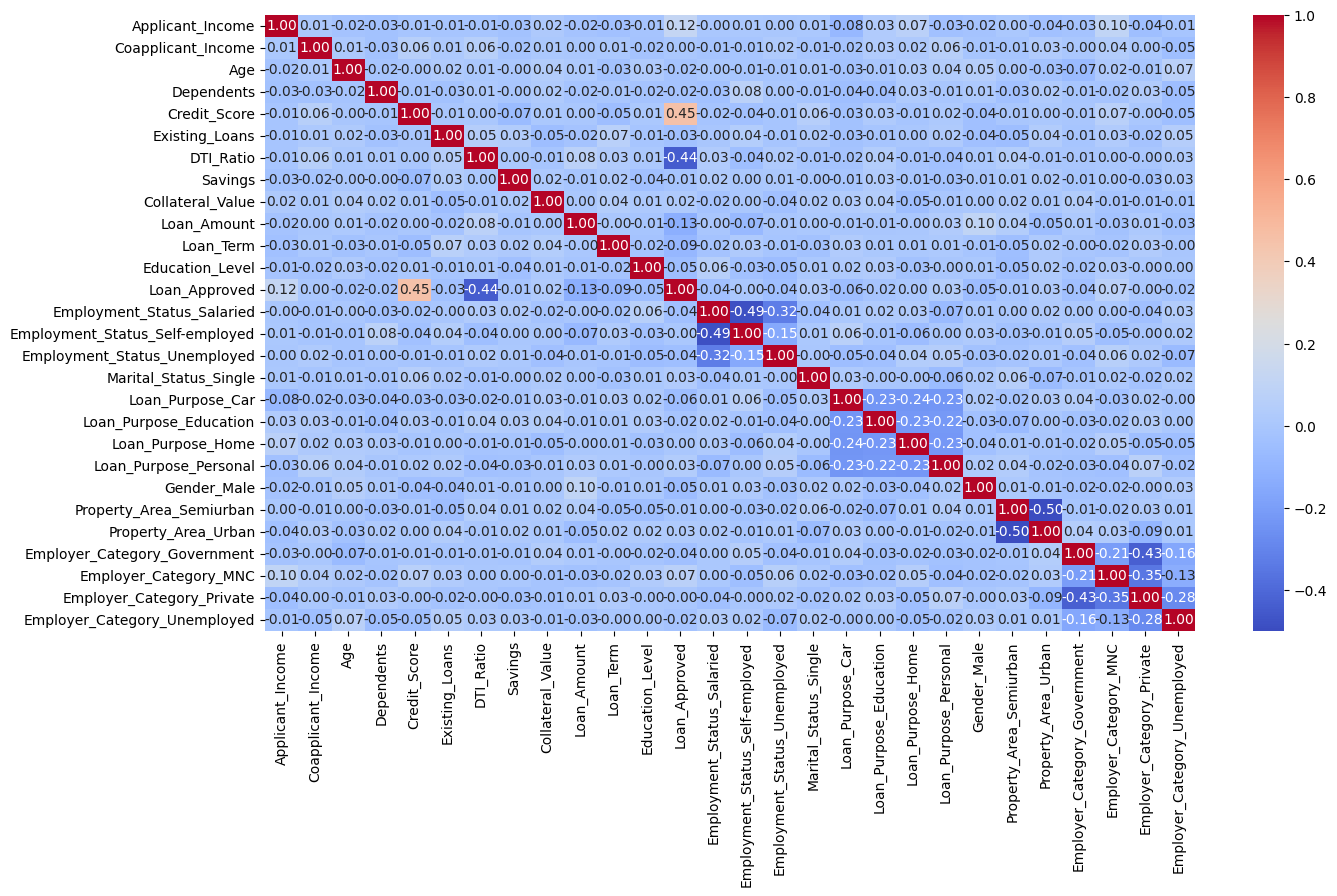

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm")

Train-Test Split + Feature Scaling

In [20]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]


In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
# Feature scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

Logistic Regression

In [23]:
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)

In [24]:
print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

precision_score:  0.7833333333333333
recall_score:  0.7704918032786885
accuracy_score:  0.865
f1_score :  0.7768595041322314
confusion_matrix:  [[126  13]
 [ 14  47]]


KNN classifier 

In [25]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)
y_pred=knn_model.predict(x_test_scaled)

In [26]:
print("KNN Model")
print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

KNN Model
precision_score:  0.6274509803921569
recall_score:  0.5245901639344263
accuracy_score:  0.76
f1_score :  0.5714285714285714
confusion_matrix:  [[120  19]
 [ 29  32]]


Naive Bayes

In [27]:
NB_model=GaussianNB()
NB_model.fit(x_train_scaled,y_train)
y_pred=NB_model.predict(x_test_scaled)

In [28]:
print("Naive Bayes Model")
print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

Naive Bayes Model
precision_score:  0.8035714285714286
recall_score:  0.7377049180327869
accuracy_score:  0.865
f1_score :  0.7692307692307693
confusion_matrix:  [[128  11]
 [ 16  45]]


Feature Engineering

In [29]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])

x=df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"])
y=df["Loan_Approved"]

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
# scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [32]:
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)

print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

precision_score:  0.7846153846153846
recall_score:  0.8360655737704918
accuracy_score:  0.88
f1_score :  0.8095238095238095
confusion_matrix:  [[125  14]
 [ 10  51]]


In [33]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)
y_pred=knn_model.predict(x_test_scaled)

print("KNN Model")
print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

KNN Model
precision_score:  0.6730769230769231
recall_score:  0.5737704918032787
accuracy_score:  0.785
f1_score :  0.6194690265486725
confusion_matrix:  [[122  17]
 [ 26  35]]


In [34]:
NB_model=GaussianNB()
NB_model.fit(x_train_scaled,y_train)
y_pred=NB_model.predict(x_test_scaled)

print("Naive Bayes Model")
print("precision_score: ",precision_score(y_test,y_pred))
print("recall_score: ",recall_score(y_test,y_pred))
print('accuracy_score: ',accuracy_score(y_test,y_pred))
print("f1_score : ",f1_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

Naive Bayes Model
precision_score:  0.8113207547169812
recall_score:  0.7049180327868853
accuracy_score:  0.86
f1_score :  0.7543859649122807
confusion_matrix:  [[129  10]
 [ 18  43]]
